#  Estimated Costs NZ



In [2]:
import json
import math
import os
from os import listdir

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pyproj
import rasterio
from geocube.api.core import make_geocube
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from shapely.geometry import Point, Polygon, box

## Constants
m2_to_ha = 0.0001
x_resolution, y_resolution = 10, 10
keep_cols = ['Attribute', 'PixelScore', 'PixelDesc', 'area_ha', 'geometry']

In [3]:
def filter_by_intersects(source_shape, filter_shape):
    """Filter one GDF by another

    From https://gis.stackexchange.com/questions/130034/what-is-the-difference-between-intersect-overlap-in-arcgis-server:
    INTERSECT returns a feature if any spatial relationship is found. Applies to all shape type combinations.
    and for overlap:
    OVERLAP returns a feature if the intersection of the two shapes results in an object of the same dimension, but different from both of the shapes.

    Args:
        source_shape (GeoDataFrame): GeoDataFrame we will filter by 
            overlap/within filter_shape
        filter_shape (GeoDataFrame): must be a GeoDataFrame with one 
        row of geometry

    Returns:
        GeoDataFrame: subset of source_shape GeoDataFrame which overlap with 
            or are contained by filter_shape 
    """
    source_shape = source_shape.copy().to_crs('epsg:2193').copy()
    filter_shape = filter_shape.copy().to_crs('epsg:2193').copy()
    # Only use geometry columns to prevent addition of additional columns
    merged = source_shape.sjoin(filter_shape[['geometry']], predicate='intersects')
    return merged.drop('index_right', axis=1)

# Load

In [3]:
%%time
# aoi_path = r'../pnvw/eco-index-pre-human-native-ecosystem-locations-for-nz.gpkg'
# aoi = gpd.read_file(aoi_path).explode(index_parts=False)
# aoi.sindex
# aoi.shape

CPU times: total: 0 ns
Wall time: 0 ns


In [4]:

# ecocatch = gpd.read_file(r'C:\Users\corey\Desktop\Eco-index\Mangaroa_Farms_Proj\3_attr_outputs\attr00\ecocatch_mangaroa.shp')

In [5]:
# aoi
# catch_path = r'C:\Users\corey\Desktop\Eco-index\Mangaroa_Farms_Proj\3_attr_outputs\attr00\ecocatch_mangaroa.shp'
# ecocatch = gpd.read_file(catch_path)
# ecocatch

status = gpd.read_file(r'../base_layers/eco-index-current-status-and-restoration-priority-for-nz.gpkg')
status = status.to_crs('epsg:2193')
status.sindex

In [4]:
catch = gpd.read_file(r'C:\Users\dav\Documents\EcoIndex\Eco-index Master GIS Layers (1)\Ei_Catchments\Ei_Catchments_v080623.shp')
catch = catch.to_crs('epsg:2193')
catch.sindex

In [7]:

# #Filter to just existing areas
# regen_mature = status[status.RestStat18.isin(['Regenerating', 'Mature'])][['RestStat18', 'geometry']]
# regen_mature.sindex

# regen_mature = regen_mature.dissolve(['RestStat18'])
# regen_mature = regen_mature.explode(index_parts=False).reset_index()
# regen_mature.sindex

restorable = status[status.RestStat18 == 'Potentially restorable'].dissolve().explode(index_parts=False)

In [6]:
status.columns

Index(['Catchment', 'PNVWmacron', 'ENA_Area_h', 'Restorable', 'Unavailabl',
       'Priority', 'ENA_prop', 'RestStat18', 'geometry'],
      dtype='object')

In [85]:
restorable = (status[status.RestStat18 == 'Potentially restorable']
              .dissolve(['Catchment', 'PNVWmacron'])
              .explode(index_parts=False).reset_index()[['Catchment', 'PNVWmacron', 'geometry']])

In [23]:
def dollar_to_decimal(value):
    if isinstance(value, float):
        return value  # If the value is already a float, return it as is.
    if isinstance(value, str):
        if value == 'No data':
            return value
        # Clean the string using a regular expression to remove non-numeric, non-decimal, and non-minus characters.
        cleaned_str = re.sub(r'[^\d.-]', '', value.strip())
        # Check if the cleaned string is a valid decimal number
        if re.match(r'^-?\d+(\.\d+)?$', cleaned_str):
            try:
                decimal_value = float(cleaned_str)
                return decimal_value
            except ValueError:
                raise ValueError(f"Invalid dollar figure after cleaning: {cleaned_str} from original {value}")
    
    return None  # Return None for invalid inputs, empty strings, or non-string/non-float data


# New Areas
## Costs

In [87]:
import re
costs_look_up = pd.read_csv(r"CostsLookUpTable_complete_2024-03-05.xlsx - PNVW_EET Costs.csv", skiprows=[0], header=0).iloc[:,:42]
costs_look_up.head()

cols = [col.strip() for col in costs_look_up.columns]
costs_look_up.columns = cols

from unidecode import unidecode
costs_look_up['PNVW'] = costs_look_up['Potential Natural Vegetation type'].apply(unidecode)
aoi['PNVW'] = aoi['PNVWmacron'].apply(unidecode)
restorable['PNVW'] = restorable['PNVWmacron'].apply(unidecode)


cost_cols_renaming = {
    'PNVW': 'PNVW', 
    'Aggregated Ecosystem type':'Aggregated Ecosystem type',
    'Calculated non-native animal species cost':'Phase3: Non-native animal species cost p.a. (per ha)',
    'Calculated non-native plant species cost':'Phase3: Non-native plant species cost p.a. (per ha)',
    # 'Calculated total plant cost reconstruction (incl. labour)': 'Phase1: Calculated total plant cost (per ha)',  
    'Calculated plant maintenance cost (3years)': 'Phase2: Early plant care cost p.a. (per ha)',
    # 'Calculated total plant cost Rehabilitation (incl. labour)': 'Rehabilitation: Calculated total plant cost',  
    'RECONSTRUCTION - RTZ ONLY SUMMED PLANTING COSTS':     'Phase1: Total planting cost (per ha)',
    # "Calculated fence cost_AVERAGE",
    "Fence costs NZ$_ 1 ha_compact_m per ha":"Phase1: Fencing scenarioA 1ha simple (per ha)",
    "Fence costs NZ$_ 1 ha_convoluted_m per ha":"Phase1: Fencing scenarioB 1ha complex (per ha)",
    "Fence costs NZ$_ 5 ha_compact_m per ha":"Phase1: Fencing scenarioC 5ha simple (per ha)",
    "Fence costs NZ$_5 ha_convoluted_m per ha":"Phase1: Fencing scenarioD 5ha complex (per ha)",
    # "Calculated fence maintenance cost per ha for average shape 5 ha patch":"Calculated fence maintenance cost per ha"
}

decimal_cols = [i for i in cost_cols_renaming.keys() if i not in ['PNVW', 'Aggregated Ecosystem type']]
for col in decimal_cols:
    print(col)
    costs_look_up[col] = costs_look_up[col].apply(dollar_to_decimal)
costs_look_up = costs_look_up[cost_cols_renaming.keys()]

costs_look_up = costs_look_up.rename(cost_cols_renaming, axis=1)
# costs_look_up['Phase2: Early plant care cost p.a. (per ha)'] = costs_look_up['Phase2: Early plant care cost p.a. (per ha)']/3 #back to per annum
print(restorable.shape)
restorable_costs = restorable.merge(costs_look_up, how='left', on='PNVW')
print(restorable_costs.shape)

Calculated non-native animal species cost
Calculated non-native plant species cost
Calculated plant maintenance cost (3years)
RECONSTRUCTION - RTZ ONLY SUMMED PLANTING COSTS
Fence costs NZ$_ 1 ha_compact_m per ha
Fence costs NZ$_ 1 ha_convoluted_m per ha
Fence costs NZ$_ 5 ha_compact_m per ha
Fence costs NZ$_5 ha_convoluted_m per ha
(248710, 4)
(248710, 13)


In [89]:
restorable_costs = restorable_costs.drop('PNVW', axis=1)
restorable_costs = restorable_costs.rename({'PNVWmacron':'Expected Ecosystem Type'}, axis=1)
cost_cols =[ 'Catchment', 'Expected Ecosystem Type','Aggregated Ecosystem type',
       'Phase3: Non-native animal species cost p.a. (per ha)',
       'Phase3: Non-native plant species cost p.a. (per ha)',
       'Phase2: Early plant care cost p.a. (per ha)',
       'Phase1: Total planting cost (per ha)',
       'Phase1: Fencing scenarioA 1ha simple (per ha)',
       'Phase1: Fencing scenarioB 1ha complex (per ha)',
       'Phase1: Fencing scenarioC 5ha simple (per ha)',
       'Phase1: Fencing scenarioD 5ha complex (per ha)', 'geometry',]
restorable_costs[cost_cols].to_file(r"output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_20240716_NZ_new.gpkg")


#### Calculate totals per type, per catchment

In [142]:
%%time
restorable_costs_catch_type = restorable_costs.dissolve(
     by=["Catchment", 'Aggregated Ecosystem type'],
     aggfunc='first',
    # index_parts=False
)
restorable_costs_catch_type = restorable_costs_catch_type.drop('Expected Ecosystem Type', axis=1)
restorable_costs_catch_type = restorable_costs_catch_type.reset_index()

per_ha_cols = ['Phase3: Non-native animal species cost p.a. (per ha)',
       'Phase3: Non-native plant species cost p.a. (per ha)',
       'Phase2: Early plant care cost p.a. (per ha)',
       'Phase1: Total planting cost (per ha)',
       'Phase1: Fencing scenarioA 1ha simple (per ha)',
       'Phase1: Fencing scenarioB 1ha complex (per ha)',
       'Phase1: Fencing scenarioC 5ha simple (per ha)',
       'Phase1: Fencing scenarioD 5ha complex (per ha)']

total_cols = [col.replace(' (per ha)', '') for col in per_ha_cols]

for per_ha_col, total_col in zip(per_ha_cols, total_cols):
    restorable_costs_catch_type['Area_ha'] = restorable_costs_catch_type.area * m2_to_ha
    restorable_costs_catch_type[total_col] = restorable_costs_catch_type[per_ha_col] * restorable_costs_catch_type.Area_ha

In [140]:
# We need to sum the totals, but ditch the per ha amounts
agg_funcs = {}
for per_ha_col, total_col in zip(per_ha_cols, total_cols):
    # agg_funcs[per_ha_col] = 'first'
    agg_funcs[total_col] = 'sum' 

In [118]:
restorable_costs_catch_type[cost_cols].to_file(r"output_layers/nz/reconstruction_costs_agg_20240716.gpkg")


#### Calculate totals per catchment

In [145]:
restorable_costs_catch = (restorable_costs_catch_type
                          .drop(per_ha_cols, axis=1)
                          .dissolve(by="Catchment",
                                    aggfunc='sum'))

C:\Users\dav\AppData\Local\Temp\ipykernel_988792\4117365541.py:1: FutureWarning: The default value of numeric_only in aggfunc='sum' within pandas.DataFrameGroupBy.agg used in dissolve is deprecated. In pandas 2.0, numeric_only will default to False. Either specify numeric_only as additional argument in dissolve() or select only columns which should be valid for the function.
  restorable_costs_catch = (restorable_costs_catch_type


In [149]:
restorable_costs_catch.to_file(r"output_layers/nz/reconstruction_costs_agg_catch_20240716.gpkg")


In [51]:
restorable_costs_catch = gpd.read_file(r"output_layers/nz/reconstruction_costs_agg_catch_20240716.gpkg")


In [116]:
# !jupyter labextension install @ryantam626/jupyterlab_code_formatter


In [117]:
# !jupyter serverextension enable --py jupyterlab_code_formatter
# # 

# Existing Areas

In [5]:
lcdb_path = r'../external_layers/lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp'
lcdb = gpd.read_file(lcdb_path)
lcdb = lcdb.to_crs('epsg:2193')
lcdb.sindex
# lcdb = lcdb[['Name_2018', 'Wetland_18', 'RestStat18', 'LCDB_UID', 'geometry']]

In [6]:
catch = gpd.read_file(r'C:\Users\dav\Documents\EcoIndex\Eco-index Master GIS Layers (1)\Ei_Catchments\Ei_Catchments_v080623.shp')
catch = catch.to_crs('epsg:2193')
catch.sindex

### Joint to TOT to get Land cover status

In [7]:
tot = pd.read_csv('TABLE OF TRUTH_Mapping LCDB and PNVW to realms and land status.xlsx - LCDB mapping.csv')

anys = tot.loc[tot['LCDB Wetland context'] == 'any', :].copy()
anys['LCDB Wetland context'] = anys.shape[0]*[['Yes', 'No']]
anys['LCDB Wetland context'] = anys.shape[0]*[['Yes', 'No']]

tot['LCDB_5 Land cover class'] = tot['LCDB_5 Land cover class'].str.replace('–', '-')
tot = pd.concat([
    anys.explode('LCDB Wetland context'), # the ones we have added
    tot[tot['LCDB Wetland context'] != 'any']
]).reset_index(drop=True)
tot['LCDB Wetland context'] = tot['LCDB Wetland context'].str.lower()
tot_sub = tot[['LCDB_5 Land cover class', 'LCDB Wetland context', 'Land cover status']]
print(lcdb.shape)
lcdb_tot = lcdb.merge(tot_sub, how='inner', left_on = ['Name_2018', 'Wetland_18'], right_on=['LCDB_5 Land cover class', 'LCDB Wetland context'])
print(lcdb.shape)

(511104, 24)
(511104, 24)


In [8]:
lcdb_tot['Land cover status'] = lcdb_tot['Land cover status'].str.strip()
lcdb_tot['Land cover status'].unique()

array(['Mature', 'Regenerating', 'Unavailable for reconstruction',
       'Potentially available for reconstruction',
       'Mature (but in need of restoration)'], dtype=object)

In [11]:
lcdb_mature_regen = lcdb_tot[lcdb_tot['Land cover status'].isin(['Mature', 'Regenerating', 'Mature (but in need of restoration)'])]
lcdb_mature_regen.loc[lcdb_tot['Land cover status']=='Mature (but in need of restoration)', 'Land cover status'] = 'Mature'

In [15]:
%%time 
#Wall time: 23min 35s
lcdb_mature_regen = lcdb_mature_regen.overlay(catch)

UsageError: Can't use statement directly after '%%time'!


In [20]:
lcdb_mature_regen.columns

Index(['Name_2018', 'Name_2012', 'Name_2008', 'Name_2001', 'Name_1996',
       'Class_2018', 'Class_2012', 'Class_2008', 'Class_2001', 'Class_1996',
       'Wetland_18', 'Wetland_12', 'Wetland_08', 'Wetland_01', 'Wetland_96',
       'Onshore_18', 'Onshore_12', 'Onshore_08', 'Onshore_01', 'Onshore_96',
       'EditAuthor', 'EditDate', 'LCDB_UID', 'LCDB_5 Land cover class',
       'LCDB Wetland context', 'Land cover status', 'Catchment', 'geometry'],
      dtype='object')

In [21]:
# status = status.reset_index()
# lcdb_status = lcdb.overlay(status)

### Join to costs table

In [41]:
import re
costs_look_up_ena = pd.read_csv("CostsLookUpTable_complete_2024-03-05.xlsx - ENA Costs.csv", skiprows=[0], header=0)

for i in costs_look_up_ena.columns:
    print(i)

cost_cols_ena_renaming = {
'LCDB_5 Land cover class': 'LCDB class',
'Wetland contex': 'Wetland context',
# 'Existing Natural Area': 
'ENA Group': 'ENA Group',
# 'non-native animal species management need'
# 'non-native plant species management need': 
# 'BASE ONGOING non-native animal species MAINTENANCE': 
'Calculated non-native animal species cost': 'Phase3: Non-native animal species cost p.a. (per ha)',
# 'BASE ONGOING non-native plant species MAINTENANCE': 
'Calculated non-native plant species cost': 'Phase3: Non-native plant species cost p.a. (per ha)',
# 'Fencing likihood': 
# 'BASE FENCE COST': 
# 'Calculated fence cost': 
'Calculated fence maintenance cost\n': "Phase3: Fence maintenance costs p.a. (per ha)",
# 'Calculated fence maintenance cost\n': 
}
str_cols = ['LCDB_5 Land cover class', 'Wetland contex', 'ENA Group']
decimal_cols_ena = [i for i in cost_cols_ena_renaming.keys() if i not in str_cols]
for col in decimal_cols_ena:
    print(col)
    costs_look_up_ena[col] = costs_look_up_ena[col].apply(dollar_to_decimal)

costs_look_up_ena = costs_look_up_ena[cost_cols_ena_renaming.keys()]

costs_look_up_ena = costs_look_up_ena.rename(cost_cols_ena_renaming, axis=1)


anys = costs_look_up_ena.loc[costs_look_up_ena['Wetland context'] == 'any', :].copy()
anys['Wetland context'] = anys.shape[0]*[['Yes', 'No']]
anys['Wetland context'] = anys.shape[0]*[['Yes', 'No']]

costs_look_up_ena['LCDB class'] = costs_look_up_ena['LCDB class'].str.replace('–', '-')
costs_look_up_ena = pd.concat([
    anys.explode('Wetland context'), # the ones we have added
    costs_look_up_ena[costs_look_up_ena['Wetland context'] != 'any']
]).reset_index(drop=True)
costs_look_up_ena['Wetland context'] = costs_look_up_ena['Wetland context'].str.lower()

# Join 
ena_cost = lcdb_mature_regen.merge(costs_look_up_ena, left_on=['Name_2018', 'Wetland_18'],right_on=['LCDB class', 'Wetland context'], how='inner')
# ena_cost = ena_cost.drop(['ENA_Area_h', 'Restorable', 'Unavailabl', 'Priority', 'ENA_prop'], axis=1)

#should be none
ena_cost[ena_cost['LCDB class'].isna()][['Name_2018', 'Wetland_18']].drop_duplicates()


LCDB_5 Land cover class
Wetland contex
Existing Natural Area
ENA Group
non-native animal species management need
non-native plant species management need
BASE ONGOING non-native animal species MAINTENANCE
Calculated non-native animal species cost
BASE ONGOING non-native plant species MAINTENANCE
Calculated non-native plant species cost
Fencing likihood
BASE FENCE COST
Calculated fence cost
BASE FENCE MAINTENANCE
Calculated fence maintenance cost

Calculated non-native animal species cost
Calculated non-native plant species cost
Calculated fence maintenance cost



,Name_2018,Wetland_18


### Get total cost

In [42]:
per_ha_cols = [col for col in ena_cost.columns if col.endswith('(per ha)')]
total_cols = [col.replace(' (per ha)', '') for col in per_ha_cols]

for per_ha_col, total_col in zip(per_ha_cols, total_cols):
    ena_cost['Area_ha'] = ena_cost.area * m2_to_ha
    ena_cost[total_col] = ena_cost[per_ha_col] * ena_cost.Area_ha

#### Aggregate to catchment level

In [43]:
drop_cols = ['Name_2018', 'Name_2012', 'Name_2008', 'Name_2001', 'Name_1996',
       'Class_2018', 'Class_2012', 'Class_2008', 'Class_2001', 'Class_1996',
       'Wetland_18', 'Wetland_12', 'Wetland_08', 'Wetland_01', 'Wetland_96',
       'Onshore_18', 'Onshore_12', 'Onshore_08', 'Onshore_01', 'Onshore_96',
       'EditAuthor', 'EditDate','LCDB_UID']
ena_cost = ena_cost.drop(drop_cols, axis=1)


In [47]:
%%time
ena_cost = (ena_cost[['Catchment'] + total_cols + ['Area_ha', 'geometry']]
                          .dissolve(by="Catchment", aggfunc='sum'))

CPU times: total: 2min 57s
Wall time: 2min 58s


In [48]:
ena_cost['Area_ha_QA'] = ena_cost.area * m2_to_ha


<AxesSubplot: >

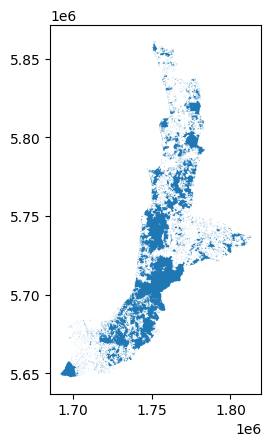

In [71]:
ena_cost.sample(1).plot()

In [54]:
restorable_costs_catch.set_index('Catchment').to_file(r"output_layers/nz/reconstruction_costs_agg_catch_20240720.gpkg")

In [50]:
ena_cost.to_file(r"output_layers/nz/maintenance_costs_agg_catch_20240720.gpkg")

In [77]:
restorable_costs_catch['New or Existing Area'] = 'New'
ena_cost['New or Existing Area'] = 'Existing'

In [79]:
restorable_costs_catch = restorable_costs_catch.set_index('Catchment')

In [80]:
comb = gpd.GeoDataFrame(pd.concat([restorable_costs_catch, ena_cost]))

In [82]:
comb = comb[['New or Existing Area', 'Phase3: Non-native animal species cost p.a.',
       'Phase3: Non-native plant species cost p.a.',
       'Phase2: Early plant care cost p.a.', 'Phase1: Total planting cost',
       'Phase1: Fencing scenarioA 1ha simple',
       'Phase1: Fencing scenarioB 1ha complex',
       'Phase1: Fencing scenarioC 5ha simple',
       'Phase1: Fencing scenarioD 5ha complex', 
       'Phase3: Fence maintenance costs p.a.', 'geometry']]
comb.to_file(r"output_layers/nz/costs_new_and_existing_per_catchment_ALL_NZ_NODISSOLVE_20240720.gpkg")

comb_diss = comb.reset_index().dissolve(['Catchment',  'New or Existing Area'], aggfunc='sum')
comb_diss.to_file(r"output_layers/nz/costs_new_and_existing_per_catchment_ALL_NZ_20240720.gpkg")

In [83]:
comb_diss2 = comb.reset_index().dissolve(['Catchment'], aggfunc='sum')


C:\Users\dav\AppData\Local\Temp\ipykernel_11828\394853843.py:1: FutureWarning: The default value of numeric_only in aggfunc='sum' within pandas.DataFrameGroupBy.agg used in dissolve is deprecated. In pandas 2.0, numeric_only will default to False. Either specify numeric_only as additional argument in dissolve() or select only columns which should be valid for the function.
  comb_diss2 = comb.reset_index().dissolve(['Catchment'], aggfunc='sum')


In [89]:
# for col in comb_diss2.columns:
#     if col != 'geometry':
#         comb_diss2[col] = comb_diss2[col].round(2)
comb_diss2.to_file(r"output_layers/nz/costs_new_and_existing_per_catchment_ALL_NZ_Catch_20240720.gpkg")

In [87]:
comb_diss2

,geometry,Phase3: Non-native animal species cost p.a.,Phase3: Non-native plant species cost p.a.,Phase2: Early plant care cost p.a.,Phase1: Total planting cost,Phase1: Fencing scenarioA 1ha simple,Phase1: Fencing scenarioB 1ha complex,Phase1: Fencing scenarioC 5ha simple,Phase1: Fencing scenarioD 5ha complex,Phase3: Fence maintenance costs p.a.
Catchment,,,,,,,,,,
Aparima,"MULTIPOLYGON (((1196121.800 4851622.489, 11961...",5.038912e+06,1.511082e+07,8.907907e+08,2.553555e+09,1.734076e+09,2.167493e+09,8.399240e+08,1.292504e+09,10385.381097
Ashburton-Hinds,"MULTIPOLYGON (((1440427.132 5163745.783, 14404...",9.557616e+06,2.931672e+07,1.790120e+09,5.131568e+09,3.702004e+09,4.627288e+09,1.793118e+09,2.759312e+09,7193.943538
Auckland Basin,"MULTIPOLYGON (((1742638.864 5916184.091, 17426...",3.268025e+06,9.826315e+06,5.146171e+08,1.475211e+09,9.833358e+08,1.229112e+09,4.762924e+08,7.329355e+08,6856.638007
Auckland offshore islands,"MULTIPOLYGON (((1764767.825 5924896.868, 17647...",2.564184e+05,5.929731e+05,1.071310e+07,3.071014e+07,2.299875e+07,2.874709e+07,1.113977e+07,1.714226e+07,1231.769284
Awatere,"MULTIPOLYGON (((1616570.001 5328271.726, 16165...",5.647062e+06,1.461092e+07,7.113439e+08,2.039144e+09,1.656235e+09,2.070197e+09,8.022207e+08,1.234485e+09,12072.101114
...,...,...,...,...,...,...,...,...,...,...
Ākitio,"MULTIPOLYGON (((1862543.781 5494680.554, 18625...",3.241859e+06,7.709628e+06,5.861165e+08,1.680168e+09,1.170447e+09,1.462990e+09,5.669222e+08,8.723997e+08,3758.258685
Ōhāriu,"MULTIPOLYGON (((1738590.920 5422725.691, 17385...",5.313076e+05,1.030533e+06,4.994336e+07,1.431676e+08,1.068744e+08,1.335867e+08,5.176610e+07,7.965948e+07,1756.163898
Ōpōtiki,"MULTIPOLYGON (((1952982.327 5766395.355, 19529...",7.663980e+06,1.636474e+07,3.313247e+08,9.497755e+08,7.010184e+08,8.762318e+08,3.395481e+08,5.225084e+08,36638.247714


In [72]:
gpd.GeoDataFrame(pd.concat([restorable_costs_catch, ena_cost]))